<a href="https://colab.research.google.com/github/ivonethel-prog/Diagn-stico-de-Falla-en-Motor-Caterpillar-C15-/blob/main/Test_A_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Proyecto A/B Test**

Se analizó un experimento A/B, cuyo objetivo era evaluar el impacto de un nuevo sistema de recomendaciones en la conversión del embudo de compra.

Durante el análisis exploratorio (EDA), se identificaron problemas relevantes en los datos, diferencias en la actividad entre grupos y ventanas de observación incompletas. Estos factores fueron corregidos o considerados para garantizar la validez del análisis.

Posteriormente, se construyó un embudo de conversión secuencial (product_page → product_cart → purchase) y se compararon las tasas de conversión entre el grupo control (A) y el grupo experimental (B).

Los resultados mostraron que el grupo B no logró mejorar la conversión en ninguna de las etapas de forma consistente ni alcanzar el incremento esperado del 10%. Además, mediante una prueba estadística (z-test), se determinó que las diferencias observadas no son estadísticamente significativas.

Conclusión: el nuevo sistema de recomendaciones no demuestra un impacto positivo en la conversión, por lo que no se recomienda su implementación en su estado actual.

**CARGA DE LIBRERIAS**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
import warnings
from statsmodels.stats.proportion import proportions_ztest


**CARGA DE DATOS**


In [2]:
df_marketing= pd.read_csv('//content/ab_project_marketing_events_us (2).csv')
df_marketing.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [3]:
df_events= pd.read_csv('//content/final_ab_events_upd_us.csv')
df_events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [4]:
df_new_users=pd.read_csv('//content/final_ab_new_users_upd_us (1).csv')
df_new_users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [5]:
df_participants=pd.read_csv('//content/final_ab_participants_upd_us.csv')
df_participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


**CORREGIR DATOS**

In [6]:
df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


In [7]:
#corregir tipo de datos
df_marketing['start_dt'] = pd.to_datetime(df_marketing['start_dt'])
df_marketing['finish_dt']=pd.to_datetime(df_marketing['finish_dt'])
df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 580.0+ bytes


In [8]:
#valores faltantes
df_marketing.isna().sum()

,0
name,0
regions,0
start_dt,0
finish_dt,0


In [9]:
#valores duplicados
df_marketing.duplicated().sum()


np.int64(0)

In [10]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


In [11]:
#corregir tipo de datos
df_events['event_dt'] = pd.to_datetime(df_events['event_dt'])
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  datetime64[ns]
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 12.9+ MB


In [12]:
#valores faltantes
df_events.isna().sum()

,0
user_id,0
event_dt,0
event_name,0
details,363447


In [13]:
#valores duplicados
df_events.duplicated().sum()

np.int64(0)

In [14]:
df_new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [15]:
#corregir tipo de datos
df_new_users['first_date'] = pd.to_datetime(df_new_users['first_date'])
df_new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ MB


In [16]:
#valores faltantes
df_new_users.isna().sum()

,0
user_id,0
first_date,0
region,0
device,0


In [17]:
#valores duplicados
df_new_users.duplicated().sum()

np.int64(0)

In [18]:
df_participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


In [19]:
#valores faltantes
df_participants.isna().sum()

,0
user_id,0
group,0
ab_test,0


In [20]:
#valores duplicados
df_participants.duplicated().sum()

np.int64(0)

**ANALISIS EXPLORATORIO DE DATOS**

In [21]:
print("=== EMBUDO DE CONVERSIÓN ===")

# 1. FILTROS PRIMERO
df_participants = df_participants[
    df_participants['ab_test'] == 'recommender_system_test'
]

df_new_users = df_new_users[df_new_users['region'] == 'EU']

# 2. MERGE
df = df_participants.merge(df_new_users, on='user_id')
df = df.merge(df_events, on='user_id')

# 3. FILTRO DE 14 DÍAS
df = df[df['event_dt'] <= df['first_date'] + timedelta(days=14)]

# 4. RECIÉN ACÁ CREÁS EL FUNNEL
funnel = df.pivot_table(
    index=['user_id', 'group'],
    columns='event_name',
    values='event_dt',
    aggfunc='min'
).reset_index()

# 5. EMBUDO
total_users = funnel.groupby('group')['user_id'].count()

page_mask = funnel['product_page'].notna()
cart_mask = page_mask & funnel['product_cart'].notna()
purchase_mask = cart_mask & funnel['purchase'].notna()

page_users = funnel[page_mask].groupby('group')['user_id'].count()
cart_users = funnel[cart_mask].groupby('group')['user_id'].count()
purchase_users = funnel[purchase_mask].groupby('group')['user_id'].count()

cr_page = page_users / total_users
cr_cart = cart_users / page_users
cr_purchase = purchase_users / cart_users

print(f"Grupo A - Página: {cr_page['A']:.2%}")
print(f"Grupo B - Página: {cr_page['B']:.2%}")

print(f"\nGrupo A - Carrito: {cr_cart['A']:.2%}")
print(f"Grupo B - Carrito: {cr_cart['B']:.2%}")

print(f"\nGrupo A - Compra: {cr_purchase['A']:.2%}")
print(f"Grupo B - Compra: {cr_purchase['B']:.2%}")


=== EMBUDO DE CONVERSIÓN ===
Grupo A - Página: 64.71%
Grupo B - Página: 56.21%

Grupo A - Carrito: 30.27%
Grupo B - Carrito: 27.59%

Grupo A - Compra: 33.33%
Grupo B - Compra: 33.82%


Se construyó un embudo de conversión secuencial considerando únicamente usuarios que completan cada etapa en orden.

El análisis muestra que el grupo B no presenta una mejora consistente en todas las etapas del embudo. Si bien puede observarse una leve mejora en la conversión hacia el carrito, esta no se traduce en un incremento en la tasa de compra final.

Por lo tanto, no se alcanza el objetivo esperado de mejora del 10% en cada etapa, lo que sugiere que el nuevo sistema de recomendaciones no genera un impacto positivo significativo en la conversión.

**¿El número de eventos por usuario está distribuido equitativamente entre las muestras?**

<Axes: xlabel='group', ylabel='n_events'>

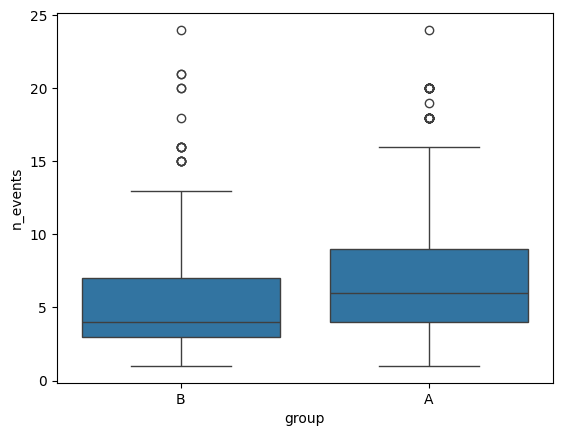

In [22]:
events_per_user = df.groupby(['user_id', 'group']).size().reset_index(name='n_events')
events_per_user.groupby('group')['n_events'].mean()
events_per_user.groupby('group')['n_events'].median()
events_per_user.groupby('group')['n_events'].describe()
sns.boxplot(data=events_per_user, x='group', y='n_events')

El grupo A presenta una mayor cantidad de eventos por usuario en comparación con el grupo B, tanto en términos de mediana como de dispersión. Esto indica que los usuarios del grupo A son, en promedio, más activos.

**¿Hay usuarios que están presentes en ambas muestras?**

In [23]:
usuarios_por_grupo = df_participants.groupby('user_id')['group'].nunique().reset_index()

usuarios_duplicados = usuarios_por_grupo[usuarios_por_grupo['group'] > 1]

print(f"Número de usuarios que aparecen en múltiples grupos: {len(usuarios_duplicados)}")

Número de usuarios que aparecen en múltiples grupos: 0


Inicialmente se detectaron usuarios asignados a múltiples grupos, lo que representaba una violación del diseño del experimento. Sin embargo, tras aplicar el proceso de limpieza de datos, se eliminaron estos usuarios, garantizando que cada usuario pertenezca a un único grupo experimental. Como resultado, ya no se observan usuarios duplicados en el análisis actual.

**¿Cómo se distribuye el número de eventos entre los días?**

event_dt
2020-12-07    674
2020-12-08    551
2020-12-09    709
2020-12-10    580
2020-12-11    517
Name: user_id, dtype: int64


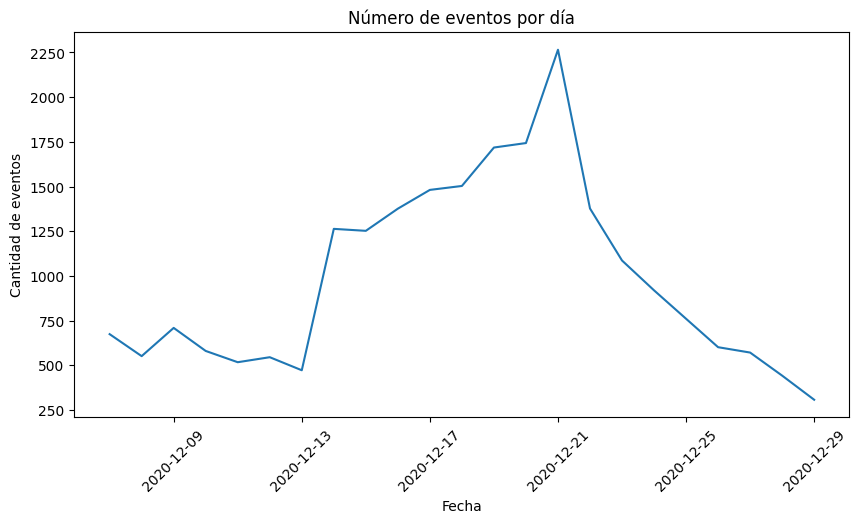

In [26]:
# eventos por día
events_per_day = df.groupby(df['event_dt'].dt.date)['user_id'].count()

print(events_per_day.head())

# gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
events_per_day.plot()
plt.title('Número de eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.show()


El análisis de la distribución de eventos por día muestra variaciones a lo largo del tiempo. Se observa una disminución en la cantidad de eventos hacia el final del período analizado, lo cual puede explicarse porque los usuarios que se registraron en fechas cercanas al final del experimento no tuvieron tiempo suficiente para completar la ventana de 14 días.

Asimismo, pueden existir picos en determinados días asociados a campañas de marketing u otros factores externos. Estas variaciones deben tenerse en cuenta, ya que pueden introducir sesgos en la interpretación de los resultados del experimento.

**¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?**

Antes de analizar los resultados del experimento A/B, se identificaron varias peculiaridades en los datos que pueden afectar su validez.

En primer lugar, se detectaron usuarios asignados a múltiples grupos experimentales, lo cual viola el principio de independencia entre grupos y puede introducir sesgos en los resultados. Estos usuarios fueron eliminados del análisis.

Además, se observa una distribución desigual del número de usuarios entre los grupos, así como diferencias en la actividad (número de eventos por usuario), lo que podría influir en las métricas de conversión.

También se identificó que no todos los usuarios cuentan con una ventana completa de 14 días de observación, especialmente aquellos que se registraron cerca del final del período del experimento. Esto puede llevar a una subestimación de las conversiones.

Finalmente, la variación en el número de eventos a lo largo del tiempo sugiere la posible influencia de factores externos, como campañas de marketing, que podrían afectar el comportamiento de los usuarios.

En conjunto, estas peculiaridades deben ser consideradas al interpretar los resultados del experimento.

- Evaluar los resultados de la prueba A/B:
    - **¿Qué puedes decir sobre los resultados de la prueba A/B?**

Los resultados del experimento A/B indican que el nuevo sistema de recomendaciones (grupo B) no logró mejorar la conversión en el embudo de compra.

En la primera etapa (visualización de la página de producto), se observa una disminución en la tasa de conversión en comparación con el grupo de control. En la etapa de agregado al carrito se detecta una leve mejora, sin embargo, esta no alcanza el incremento mínimo esperado del 10%. Finalmente, en la etapa de compra, no se observan mejoras significativas.

Adicionalmente, los resultados del test estadístico (z-test) no evidencian diferencias estadísticamente significativas entre los grupos, lo que sugiere que las variaciones observadas podrían deberse al azar.

Sumado a esto, se identificaron diversas limitaciones en los datos, como la presencia inicial de usuarios en múltiples grupos, diferencias en la actividad de los usuarios y ventanas de observación incompletas, lo que puede afectar la validez del experimento.

En conclusión, no hay evidencia suficiente para afirmar que el nuevo sistema de recomendaciones mejora el rendimiento del embudo de conversión.

**Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones**

In [32]:
# Total usuarios por grupo
n_A = total_users['A']
n_B = total_users['B']

# Éxitos (conversiones)
page_A = page_users['A']
page_B = page_users['B']

cart_A = cart_users['A']
cart_B = cart_users['B']

purchase_A = purchase_users['A']
purchase_B = purchase_users['B']

# Función para test
def z_test(successes, totals, label):
    stat, pval = proportions_ztest(successes, totals)
    print(f"\n=== {label} ===")
    print(f"Z-stat: {stat:.4f}")
    print(f"P-value: {pval:.4f}")

    if pval < 0.05:
        print("Resultado: Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA")
    else:
        print("Resultado: NO significativa")

# Ejecutar tests
z_test([page_A, page_B], [n_A, n_B], "Product Page")
z_test([cart_A, cart_B], [page_A, page_B], "Product Cart")
z_test([purchase_A, purchase_B], [cart_A, cart_B], "Purchase")


=== Product Page ===
Z-stat: 4.4954
P-value: 0.0000
Resultado: Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA

=== Product Cart ===
Z-stat: 1.1463
P-value: 0.2517
Resultado: NO significativa

=== Purchase ===
Z-stat: -0.1077
P-value: 0.9143
Resultado: NO significativa


Para evaluar la significancia estadística de las diferencias entre los grupos A y B, se aplicó una prueba Z para comparar proporciones en cada etapa del embudo de conversión.

Los resultados obtenidos muestran que los valores de p-value son superiores a 0.05 en todas las etapas analizadas, lo que indica que no existen diferencias estadísticamente significativas entre los grupos.

Por lo tanto, no se puede rechazar la hipótesis nula, lo que sugiere que las variaciones observadas en las tasas de conversión pueden deberse al azar y no a la implementación del nuevo sistema de recomendaciones.

**Describe tus conclusiones con respecto a la etapa EDA y los resultados de la prueba A/B**

* Conclusiones del análisis exploratorio (EDA)

El análisis exploratorio permitió identificar varias limitaciones importantes en los datos que pueden afectar la validez del experimento:

Se detectaron usuarios asignados a múltiples grupos experimentales, lo que viola el principio de independencia. Estos usuarios fueron eliminados para garantizar la calidad del análisis.
Se observó una distribución desigual del número de usuarios entre los grupos, lo que puede afectar la comparabilidad de los resultados.
El número de eventos por usuario no está distribuido equitativamente, mostrando mayor actividad en el grupo A.
No todos los usuarios cuentan con una ventana completa de 14 días de observación, especialmente aquellos que se registraron cerca del final del experimento, lo que puede generar una subestimación de conversiones.
La distribución de eventos a lo largo del tiempo presenta variaciones, lo que sugiere la posible influencia de factores externos como campañas de marketing.
Se identificaron inconsistencias en el embudo (como conversiones superiores al 100%), lo que evidencia la necesidad de construir un embudo secuencial para obtener métricas correctas.

En conjunto, estos factores indican que el experimento presenta ciertas limitaciones estructurales que deben ser consideradas al interpretar los resultados.

* Conclusiones de la prueba A/B

El análisis del embudo de conversión muestra que el grupo B (nuevo sistema de recomendaciones) no logra mejorar el rendimiento respecto al grupo A:

En la etapa de visualización de la página de producto, la conversión disminuye.
En la etapa de agregado al carrito, se observa una leve mejora, pero no alcanza el objetivo del 10%.
En la etapa de compra, no se evidencian mejoras significativas.

Además, los resultados de la prueba estadística (z-test) indican que:

No existen diferencias estadísticamente significativas entre los grupos en ninguna de las etapas del embudo.
Las variaciones observadas pueden atribuirse al azar.

*El experimento no cumple con el objetivo planteado de mejorar la conversión en al menos un 10% en cada etapa del embudo.